In [6]:
# %matplotlib notebook
import pandas as pd
import numpy as np

import sys
# sys.path.append('../../OT-Velocity-local/Utils/')
# sys.path.append('../../cardamom/results_article/Benchmark_on_simulated_data/_scripts/')
# sys.path.append('../../WmB_2025_causal_GRN_inference/Methods/OTVelo/')

# from sincerities import *

# from utils_Velo import *

# from utils import *
import scipy
import scanpy
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

import sys
sys.path.append('Utils/')
from cycleGRN import bin_traj, train_ours,traj_ours,build_laplacian,find_Lie_derivative#, pick_alpha_simple
from cycleGRN import time_lagged_correlation, time_lagged_Granger, time_lagged_Granger_CV_fast,pick_k_threshold
from validation import create_matrices, visualize_truth_gene, visualize_matrix_gene, create_matrices_from_pandas
from prepare_data import *
from benchmark_harissa import benchmark_HARISSA

import scipy
import scanpy
import matplotlib.pyplot as plt

#import test_batch_modules
#from test_batch_modules import batch_test, OT_lagged_correlation, load_others_result, batch_test_BEELINE, load_others_result_BEELINE
%load_ext autoreload
%autoreload 2

# Loading data and rewriting gene names as symbols

In [68]:

data_dir = '/Users/wenjunzhao/dropbox/WmB_2025_causal_GRN_inference/mouseprogenitormtxs/'
data = prepare_data( 'early', gene_subset = True, q_num=10, data_dir=data_dir )
pheno = pd.read_csv(data_dir + '10x_mouse_retina_development_phenotype.csv')

from scipy.io import mmread
a = mmread(data_dir + 'GSE118614_10x_aggregate.mtx')
a

/Users/wenjunzhao/Dropbox/CycleGRN/Github/CycleGRN/Utils/prepare_data.py:60: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  data_subset.obs['Tricycle'] = tricycle_time['tricyclePosition']


<COOrdinate sparse matrix of dtype 'int64'
	with 139338552 stored elements and shape (120804, 27998)>

In [69]:
import mygene

mg = mygene.MyGeneInfo()
# query all genes in your dataset
mapping = mg.querymany(
    data.var_names.tolist(),
    scopes="ensembl.gene",
    fields="symbol",
    species="mouse"
)

# Convert to dictionary
ensg2symbol = {entry["query"]: entry.get("symbol", None) for entry in mapping}
data.var["gene_symbol"] = data.var_names.map(ensg2symbol)

Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
72 input query terms found no hit:	['ENSMUSG00000090399', 'ENSMUSG00000097823', 'ENSMUSG00000089788', 'ENSMUSG00000099404', 'ENSMUSG000
/var/folders/3c/t0768wrd4tzgkdw8827tgf3m0000gp/T/ipykernel_25889/875393683.py:14: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  data.var["gene_symbol"] = data.var_names.map(ensg2symbol)


In [70]:
data

AnnData object with n_obs × n_vars = 27764 × 3164
    obs: 'age', 'umap_coord1', 'umap_coord2', 'umap_coord3', 'age (days)', 'bin', 'Tricycle', 'tricycle-qcut', 'theta', 'theta-qcut'
    var: 'gene_symbol'
    uns: 'log1p'

# Take cell cycle genes and visualize

In [71]:
cell_cycle_genes = pd.read_csv('../../Data/GO_cycle_genes_mouse.txt', sep=None, engine="python")
genes_subset = list(set(list( cell_cycle_genes['MGI Gene/Marker ID'].values ) ) )
len( genes_subset )

1742

In [72]:
X = data.X.T

In [73]:
gene_mask = data.var['gene_symbol'].isin(genes_subset)
adata_subset = data[:, gene_mask].copy()
import scanpy as sc

# (optional but typical) preprocess
# sc.pp.normalize_total(adata_subset, target_sum=1e4)  # library-size normalize
# sc.pp.log1p(adata_subset)

# PCA
sc.tl.pca(adata_subset, n_comps=50, svd_solver="arpack")  # or "randomized" for speed


In [74]:
print( adata_subset.obsm['X_pca'].shape )

(27764, 50)


(np.float64(-3.858907961845398),
 np.float64(10.229508185386658),
 np.float64(-3.9754438757896424),
 np.float64(10.112972271442414))

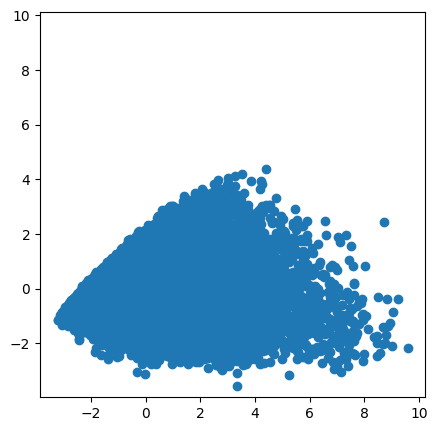

In [75]:
res = adata_subset.obsm['X_pca'][:,0:2]
res = res[subsample,:]
plt.scatter(res[:,0], res[:,1] )
plt.axis('square')

In [76]:
data

AnnData object with n_obs × n_vars = 27764 × 3164
    obs: 'age', 'umap_coord1', 'umap_coord2', 'umap_coord3', 'age (days)', 'bin', 'Tricycle', 'tricycle-qcut', 'theta', 'theta-qcut'
    var: 'gene_symbol'
    uns: 'log1p'

# Visualize Tricycle coordinates

Text(0.5, 1.0, 'Colored by Tricycle position')

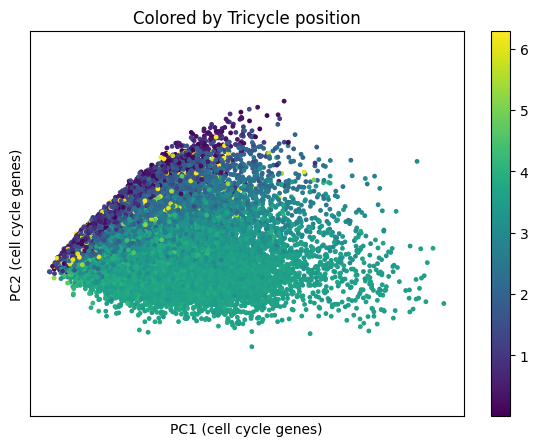

In [77]:
plt.figure(figsize=(7, 5))

# tricycle = pd.read_csv("../Data/tricycle_results.csv")
# tricycle  = tricycle .iloc[subsample]
tricycle = data.obs['Tricycle'].values
plt.scatter(res[:,0], res[:,1] , c=tricycle, s=6)
plt.xlabel('PC1 (cell cycle genes)')
plt.ylabel('PC2 (cell cycle genes)')
plt.colorbar()
plt.axis('equal'); plt.xticks([]); plt.yticks([])
plt.title('Colored by Tricycle position')
# plt.savefig('../Figures/earlyRPC_GOPC.pdf',bbox_inches='tight')

Text(0.5, 1.0, 'Colored by experimental time')

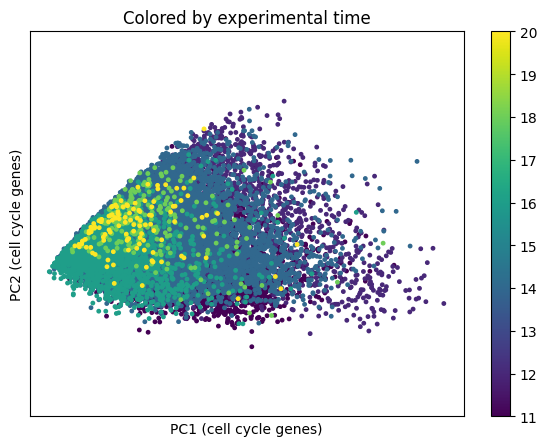

In [78]:
plt.figure(figsize=(7, 5))

plt.scatter(res[:,0], res[:,1] , c=data.obs['age (days)'], s=6)
plt.xlabel('PC1 (cell cycle genes)')
plt.ylabel('PC2 (cell cycle genes)')
plt.colorbar()
plt.axis('equal'); plt.xticks([]); plt.yticks([])
plt.title('Colored by experimental time')
# plt.savefig('../Figures/earlyRPC_exp.pdf',bbox_inches='tight')

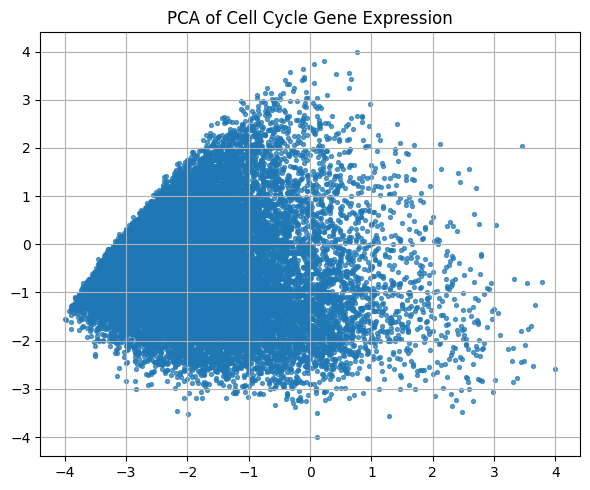

In [79]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np


# Standardize the data
pca_result = res[:, 0:2]


ys_true = (pca_result[:, :2] - pca_result[:, :2].min(0)) / np.ptp(pca_result[:, :2],0) * [8, 8] - [4, 4]


# Plot
plt.figure(figsize=(6, 5))
plt.scatter(ys_true[:, 0], ys_true[:, 1], s=8, alpha=0.7)
plt.title("PCA of Cell Cycle Gene Expression")
# plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
# plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [80]:
ys_true = (pca_result[:, :2] - pca_result[:, :2].min(0)) / np.ptp(pca_result[:, :2]) * 8 - 4

import pickle
with open('../../Data/early_RPC_PC.p', "wb") as f:
    pickle.dump([[0],ys_true], f)

In [81]:
ys2,ts2,vs2 = traj_ours(1000,'../../Data/early_RPC_PC.p',seed=0)

Plotting Dynamics
Plotting Inferred Parameter


In [82]:
import numpy as np
import scipy.sparse as sp
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt

# ---------- Core helpers ----------
def row_normalize(W):
    """Row-normalize adjacency/kernel to a random-walk matrix P."""
    if sp.issparse(W):
        rs = np.asarray(W.sum(axis=1)).ravel() + 1e-12
        return sp.diags(1.0/rs) @ W
    rs = W.sum(axis=1, keepdims=True) + 1e-12
    return W / rs

def flow_from_transition(X2d, P):
    """
    X2d: (n,2) embedding
    P  : (n,n) row-stochastic transition (sparse or dense)
    Returns per-cell flow vectors v = (P @ X - X).
    """
    if sp.issparse(P):
        PX = P @ X2d
    else:
        PX = P.dot(X2d)
    V = PX - X2d
    return V

def interpolate_to_grid(X2d, V, grid_size=60, k=30, bandwidth=None):
    """
    Interpolate per-cell vectors V onto a regular grid over X2d.
    Gaussian-weighted kNN interpolation (bandwidth auto = median NN distance).
    Returns (Xg, Yg, U, V) for streamplot/quiver.
    """
    x, y = X2d[:,0], X2d[:,1]
    xlin = np.linspace(x.min(), x.max(), grid_size)
    ylin = np.linspace(y.min(), y.max(), grid_size)
    Xg, Yg = np.meshgrid(xlin, ylin)
    grid_pts = np.c_[Xg.ravel(), Yg.ravel()]

    nbrs = NearestNeighbors(n_neighbors=min(k, len(X2d)), algorithm='auto').fit(X2d)
    dists, idxs = nbrs.kneighbors(grid_pts, return_distance=True)  # (m,k)
    if bandwidth is None:
        # median of 1-NN distances across grid points
        bandwidth = np.median(dists[:, 0]) + 1e-12

    W = np.exp(- (dists**2) / (2 * bandwidth**2))  # Gaussian weights
    W /= (W.sum(axis=1, keepdims=True) + 1e-12)

    U = (W * V[idxs, 0]).sum(axis=1).reshape(Xg.shape)
    Vv = (W * V[idxs, 1]).sum(axis=1).reshape(Xg.shape)
    return Xg, Yg, U, Vv

# ---------- Visualization ----------
def velocity_streamplot(X2d, V, use_P=True, grid_size=60, k=30, bandwidth=None,
                        density=1.2, minlength=0.5, color_by_speed=True, quiver=False):
    """
    Draw scVelo-like flows on the 2D embedding.
      - If use_P: P_or_W is a row-stochastic transition P.
      - Else:     P_or_W is an adjacency/kernel W (we row-normalize to P).
    """
    
    Xg, Yg, U, Vg = interpolate_to_grid(X2d, V, grid_size=grid_size, k=k, bandwidth=bandwidth)

    speed = np.hypot(U, Vg)
    # plt.figure(figsize=(6,5))
    # background cells
    plt.scatter(X2d[:,0], X2d[:,1], s=6, c="lightgray", alpha=0.7, linewidths=0)

    if quiver:
        step = max(1, grid_size // 25)  # sparser for readability
        Q = plt.quiver(Xg[::step,::step], Yg[::step,::step],
                       U[::step,::step], Vg[::step,::step],
                       speed[::step,::step] if color_by_speed else None,
                       angles='xy', scale_units='xy', scale=1.0, width=0.003)
        if color_by_speed:
            plt.colorbar(Q, label="speed")
    else:
        # streamplot with optional speed colormap
        strm = plt.streamplot(Xg, Yg, U, Vg, density=density, minlength=minlength,
                              color=speed if color_by_speed else 'k', linewidth=1)
        if color_by_speed:
            cbar = plt.colorbar(strm.lines)
            cbar.set_label("speed")

    plt.axis('equal'); plt.xticks([]); plt.yticks([])
    
    # plt.tight_layout(); #plt.show()

Text(0, 0.5, 'PC2 (cell cycle genes)')

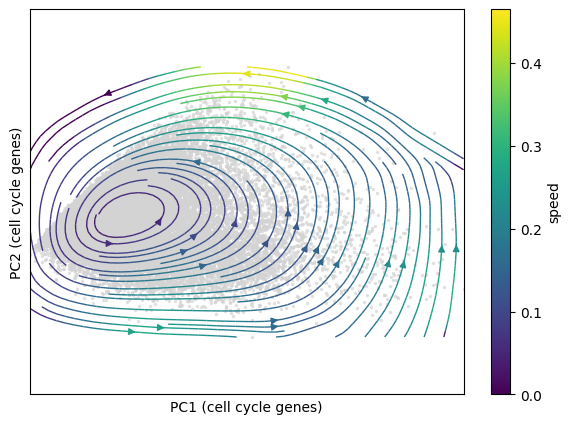

In [89]:

plt.figure(figsize=(7, 5))
# subsample_plot = range(0, ys_true.shape[0], 100)
subsample_plot = range(0,  ys_true.shape[0], 10)
# plt.quiver(ys_true[subsample_plot,0], ys_true[subsample_plot,1], -vs2[subsample_plot,0], -vs2[subsample_plot,1], color=np.sqrt(vs2[subsample_plot,0]**2 + vs2[subsample_plot,1]**2), scale=5 )
velocity_streamplot(ys_true, vs2.detach().numpy(), use_P=False, grid_size=30, k=15, density=1.5)
plt.xlabel('PC1 (cell cycle genes)')
plt.ylabel('PC2 (cell cycle genes)')


# plt.savefig('../Figures/earlyRPC/earlyRPC_velocity.pdf',bbox_inches='tight')

In [84]:
X = data.X.T
print(X.shape)

T = build_laplacian(ys_true, vs2,X_full=None, k=400, threshold=0., stimulation=False)

(3164, 27764)


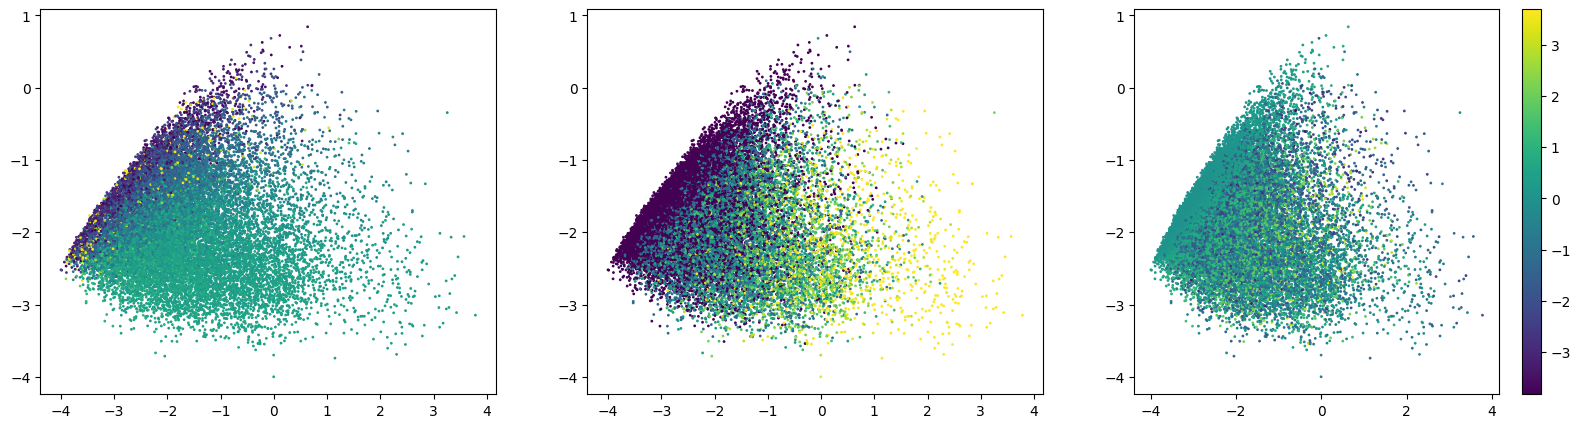

In [85]:
import scanpy as sc
plt.rcParams['figure.figsize'] = (20,5)
# Compute PCA
plt.subplot(131)
# sc.tl.pca(adata_subset, n_comps=2)
# sc.pp.neighbors(adata_subset)
# sc.tl.umap(adata_subset)

plt.scatter(ys_true[:,0],ys_true[:,1], c=tricycle,s=1 )

plt.subplot(132)
# sc.tl.pca(adata_subset, n_comps=2)
# sc.pp.neighbors(adata_subset)
# sc.tl.umap(adata_subset)
c = data[:, data.var['gene_symbol'] == 'Top2a'].X.toarray().ravel()

plt.scatter(ys_true[:,0],ys_true[:,1], c = c, s=1 )
plt.clim([0,2])

plt.subplot(133)
# sc.tl.pca(adata_subset, n_comps=2)
# sc.pp.neighbors(adata_subset)
# sc.tl.umap(adata_subset)
from scipy import sparse

V = find_Lie_derivative(X,T, stimulation=False)
# V = V.T
# V = X @ T.T - X @ T
# V = np.array(V)
V = V / (1e-15 + V.todense().std(axis=1).reshape(-1,1) )
c = V.getrow(2311).toarray().ravel() if sparse.issparse(V) else np.asarray(V[2311, :]).ravel()

plt.scatter(ys_true[:,0],ys_true[:,1], c = c, s=1 )
plt.colorbar()
# plt.clim([0,2])



plt.show()

In [86]:
V = find_Lie_derivative(X,T, stimulation=False)
V = V.todense()
V = V / (1e-15 + V.std(axis=0).reshape(1,-1) )
V = V
G = time_lagged_correlation(X,V,T)#,lag=True)#, lag=True)

G = G - np.diag(np.diag(G))

genes_subset = pd.read_csv(data_dir + '/genes_for_subset.csv',index_col = 0)
gene_names_to_subset = [str(idx) for idx in genes_subset['x'] ]
result_pandas = pd.DataFrame(G/abs(G).max()) 
        
result_pandas.index = gene_names_to_subset
result_pandas.columns = gene_names_to_subset

# result_pandas.to_csv(data_dir + 'CycleGRN_notricycle_early.csv')

# Sensitivity to hyperparameters:

In [90]:
k_list=[200,400,700,1000,1500,2000,2500]
tau_list=[0., 0.25, 0.5,0.9,0.95,0.99]
aupr = np.zeros( (len(k_list), len(tau_list) ) )

truth_file = '/Users/wenjunzhao/dropbox/WmB_2025_causal_GRN_inference/mouseprogenitormtxs/string_interactions_earlyRPC_generalRPC_NP80.tsv'
genes_file = '/Users/wenjunzhao/dropbox/WmB_2025_causal_GRN_inference/mouseprogenitormtxs/10x_mouse_retina_development_feature.csv'
for (i,k) in enumerate(k_list):
    for (j,tau) in enumerate(tau_list):
        print('k='+str(k))
        print('tau='+str(tau))
        T = build_laplacian(ys_true, vs2,X_full=None, k=k, threshold=tau, stimulation=False)
        V = find_Lie_derivative(X,T, stimulation=False)


        
        V = V.todense()
        V = V / (1e-15 + V.std(axis=0).reshape(1,-1) )
        V = V
        G = time_lagged_correlation(X,V,T, lag=False)
        
        
        G = G - np.diag(np.diag(G))
        G = G/abs(G).max()
        
        genes_subset = pd.read_csv(data_dir + '/genes_for_subset.csv',index_col = 0)
        gene_names_to_subset = [str(idx) for idx in genes_subset['x'] ]
        result_pandas = pd.DataFrame(G/abs(G).max()) 
                
        result_pandas.index = gene_names_to_subset
        result_pandas.columns = gene_names_to_subset

        score_submatrix, binary_truth, matrix, string_links_filtered = create_matrices_from_pandas(result_pandas,truth_file,genes_file)
    
        from sklearn.metrics import roc_auc_score, average_precision_score
        
        # stop
        y_score = abs(score_submatrix.values).flatten()
        y_score = y_score/y_score.max()
        y_true = binary_truth.values.flatten()
        baseline = np.mean(y_true)
        # Compute metrics
        # auroc = roc_auc_score(y_true, y_score)
        aupr[i,j] = average_precision_score(y_true, y_score)/baseline

k=200
tau=0.0
k=200
tau=0.25
k=200
tau=0.5
k=200
tau=0.9
k=200
tau=0.95
k=200
tau=0.99
k=400
tau=0.0
k=400
tau=0.25
k=400
tau=0.5
k=400
tau=0.9
k=400
tau=0.95
k=400
tau=0.99
k=700
tau=0.0
k=700
tau=0.25
k=700
tau=0.5
k=700
tau=0.9
k=700
tau=0.95
k=700
tau=0.99
k=1000
tau=0.0
k=1000
tau=0.25
k=1000
tau=0.5
k=1000
tau=0.9
k=1000
tau=0.95
k=1000
tau=0.99
k=1500
tau=0.0
k=1500
tau=0.25
k=1500
tau=0.5
k=1500
tau=0.9
k=1500
tau=0.95
k=1500
tau=0.99
k=2000
tau=0.0
k=2000
tau=0.25
k=2000
tau=0.5
k=2000
tau=0.9
k=2000
tau=0.95
k=2000
tau=0.99
k=2500
tau=0.0
k=2500
tau=0.25
k=2500
tau=0.5
k=2500
tau=0.9
k=2500
tau=0.95
k=2500
tau=0.99


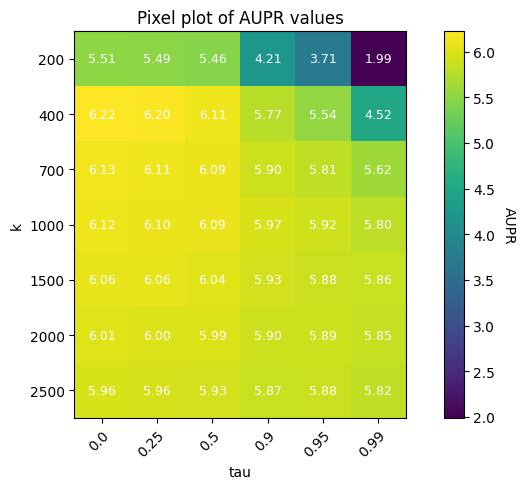

In [91]:
fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(aupr, cmap='viridis')

# Add colorbar
cbar = plt.colorbar(im)
cbar.set_label('AUPR', rotation=270, labelpad=15)

# Set axis ticks
ax.set_xticks(np.arange(len(tau_list)))
ax.set_yticks(np.arange(len(k_list)))
ax.set_xticklabels(tau_list)
ax.set_yticklabels(k_list)

ax.set_xlabel('tau')
ax.set_ylabel('k')

# Rotate x tick labels if needed
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

# Overlay the numbers
for i in range(len(k_list)):
    for j in range(len(tau_list)):
        text = ax.text(
            j, i, f"{aupr[i, j]:.2f}",
            ha="center", va="center", color="w", fontsize=9
        )

ax.set_title("Pixel plot of AUPR values")
# plt.savefig('../Figures/earlyRPC/ablation.pdf',bbox_inches='tight')
plt.tight_layout()
plt.show()